# Odds and cards versus the result

Average match odds (`AvgH`, `AvgD`, `AvgA`) turned into win probabilities, then compared with the full-time result (`FTR`).

## What `AvgH`, `AvgD`, and `AvgA` mean

These are the average prices the bookmakers set **before** the match. A smaller price means that result is more likely.

* **`AvgH`**: price for a home win
* **`AvgD`**: price for a draw
* **`AvgA`**: price for an away win

**How to read a price.** Divide 1 by the price to get the chance. A price of **2.00** is `1 / 2.00` = **50%**. A price of **4.00** is `1 / 4.00` = **25%**. The lowest of the three prices is the result the bookmakers give the biggest chance.

`FTR` is the full-time result after the match: **H** home win, **D** draw, **A** away win. The charts compare the chance from the price with that result.

On the charts, labels such as **0–20** and **20–30** are that chance as a **percentage**, not the price. **0–20** means a 0% to 20% chance. A chance that small comes from a high price, about **5.00** or more.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("combined_data.csv")
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,1.62,0.50,1.75,2.05,1.81,2.13,2.05,2.17,1.80,2.09
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,2.25,-1.00,2.05,1.75,2.17,1.77,2.19,1.93,2.10,1.79
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,1.62,0.25,1.79,2.15,1.81,2.14,1.82,2.19,1.79,2.12
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,1.94,-1.50,2.05,1.75,2.12,1.81,2.16,1.93,2.06,1.82
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,1.67,-0.50,2.05,1.88,2.05,1.88,2.08,1.90,2.03,1.86


Decimal odds are prices, not probabilities. `1 / odds` is the raw chance, and the three outcomes are scaled so they add up to 1.

In [3]:
raw = pd.DataFrame({
    "H": 1 / df["AvgH"],
    "D": 1 / df["AvgD"],
    "A": 1 / df["AvgA"],
})
imp = raw.div(raw.sum(axis=1), axis=0)
imp["FTR"] = df["FTR"].values
imp.head()

,H,D,A,FTR
0,0.240263,0.281591,0.478147,H
1,0.621104,0.214891,0.164005,H
2,0.301797,0.311564,0.386639,A
3,0.762616,0.162314,0.075070,H
4,0.488831,0.272804,0.238366,H


Each outcome is grouped into chance bands. A label such as **0–20** is a **percentage** (0% to 20% chance), not the price. The plot compares that chance with how often the result actually happened.

In [7]:
bins = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1]
labels = ["0-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70+"]

rows = []
for outcome in ["H", "D", "A"]:
    band = pd.cut(imp[outcome], bins, labels=labels, include_lowest=True)
    for name, g in imp.groupby(band, observed=True):
        if len(g) < 20:
            continue
        rows.append({
            "outcome": outcome,
            "band %": str(name),
            "n": len(g),
            "implied": g[outcome].mean() * 100,
            "actual": (g["FTR"] == outcome).mean() * 100,
        })

trend = pd.DataFrame(rows)
trend["gap"] = trend["actual"] - trend["implied"]
trend.round(1)

,outcome,band %,n,implied,actual,gap
0,H,0-20,130,13.4,10.8,-2.6
1,H,20-30,144,25.1,25.7,0.6
2,H,30-40,208,34.8,28.8,-6.0
3,H,40-50,182,44.6,43.4,-1.2
4,H,50-60,134,55.0,54.5,-0.5
5,H,60-70,109,64.9,67.9,3.0
6,H,70+,113,78.0,71.7,-6.3
7,D,0-20,202,15.8,14.4,-1.5
8,D,20-30,762,26.0,25.5,-0.6
9,D,30-40,56,30.6,25.0,-5.6


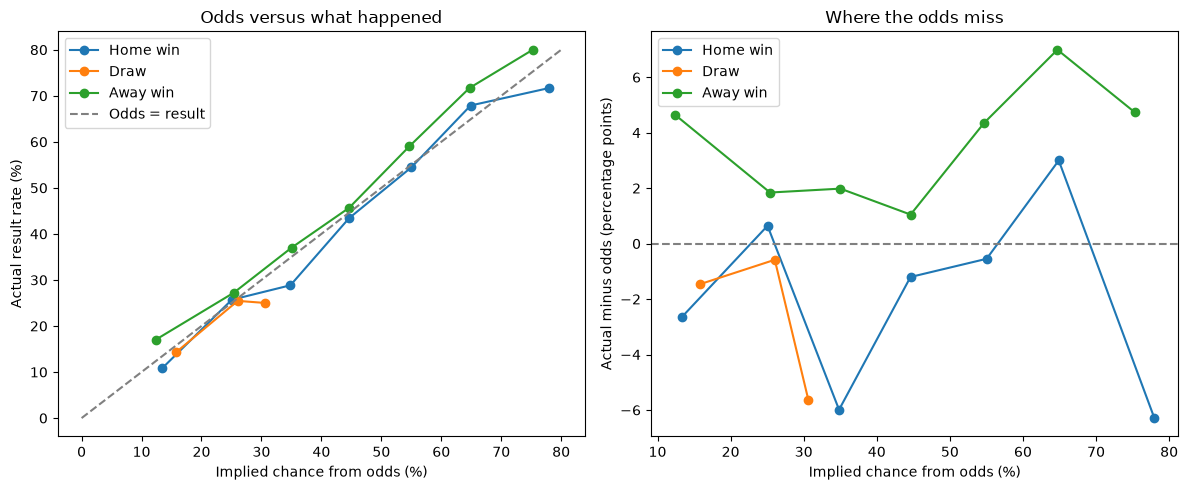

In [5]:
names = {"H": "Home win", "D": "Draw", "A": "Away win"}
colors = {"H": "#1f77b4", "D": "#ff7f0e", "A": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for outcome in ["H", "D", "A"]:
    part = trend[trend["outcome"] == outcome]
    axes[0].plot(part["implied"], part["actual"], marker="o", color=colors[outcome], label=names[outcome])
axes[0].plot([0, 80], [0, 80], linestyle="--", color="gray", label="Odds = result")
axes[0].set_xlabel("Implied chance from odds (%)")
axes[0].set_ylabel("Actual result rate (%)")
axes[0].set_title("Odds versus what happened")
axes[0].legend()

for outcome in ["H", "D", "A"]:
    part = trend[trend["outcome"] == outcome]
    axes[1].plot(part["implied"], part["gap"], marker="o", color=colors[outcome], label=names[outcome])
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_xlabel("Implied chance from odds (%)")
axes[1].set_ylabel("Actual minus odds (percentage points)")
axes[1].set_title("Where the odds miss")
axes[1].legend()

fig.tight_layout()
plt.show()

**Left chart.** X is the chance from the odds (%). Y is how often that result happened (%). On the dashed line, the odds matched. Above the line, it happened more often. Below the line, less often.

**Right chart.** X is the same chance (%). Y is actual minus the odds, in percentage points. Zero means the odds matched. Above zero, it happened more often. Below zero, less often.